# LeetCode #110: Balanced Binary Tree

https://leetcode.com/problems/balanced-binary-tree/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Naive (isBalanced + height per node) | O(n²) | O(n) | height() called O(n) times |
| **DFS with -1 sentinel ★** | **O(n)** | **O(n)** | Single post-order pass; -1 signals unbalanced subtree |

---

## Understanding the Methods

### Brute Force
For each node, call a separate `height()` function. This is O(n) per node × O(n) nodes = O(n²).

### DFS with -1 Sentinel (Optimal ★)
Combine height and balance check in one `checkHeight` function. Return -1 if any subtree is unbalanced, propagating immediately. Otherwise return actual height. Final call returns -1 iff tree is unbalanced.

## Constraints
- Number of nodes: [0, 5000]
- Node values: [-10⁴, 10⁴]

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsBalanced(TreeNode root) {
        return CheckHeight(root) != -1;
    }

    private int CheckHeight(TreeNode node) {
        if (node == null) return 0;
        int leftH  = CheckHeight(node.left);
        if (leftH  == -1) return -1;
        int rightH = CheckHeight(node.right);
        if (rightH == -1) return -1;
        if (Math.Abs(leftH - rightH) > 1) return -1;
        return 1 + Math.Max(leftH, rightH);
    }
}

### Python

In [ ]:
class Solution:
    def isBalanced(self, root) -> bool:
        def check_height(node) -> int:
            if not node: return 0
            left_h  = check_height(node.left)
            if left_h  == -1: return -1
            right_h = check_height(node.right)
            if right_h == -1: return -1
            if abs(left_h - right_h) > 1: return -1
            return 1 + max(left_h, right_h)
        return check_height(root) != -1

### Go

In [ ]:
func isBalanced(root *TreeNode) bool {
    return checkHeight(root) != -1
}

func checkHeight(node *TreeNode) int {
    if node == nil { return 0 }
    left := checkHeight(node.Left)
    if left == -1 { return -1 }
    right := checkHeight(node.Right)
    if right == -1 { return -1 }
    if left - right > 1 || right - left > 1 { return -1 }
    if left > right { return 1 + left }
    return 1 + right
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn is_balanced(root: Option<Rc<RefCell<TreeNode>>>) -> bool {
        Self::check_height(root) != -1
    }

    fn check_height(node: Option<Rc<RefCell<TreeNode>>>) -> i32 {
        let Some(n) = node else { return 0; };
        let left_h  = Self::check_height(n.borrow().left.clone());
        if left_h  == -1 { return -1; }
        let right_h = Self::check_height(n.borrow().right.clone());
        if right_h == -1 { return -1; }
        if (left_h - right_h).abs() > 1 { return -1; }
        1 + left_h.max(right_h)
    }
}

## Example Scenarios

### 1. Common Case — Balanced 3-Level Tree
**Input:** `root = [3, 9, 20, null, null, 15, 7]`

Post-order DFS: checkHeight(9)=1, checkHeight(15)=1, checkHeight(7)=1, checkHeight(20)=2, checkHeight(3)=3. At every node $|h_L - h_R| \le 1$. Final return $3 \ne -1$.

*Why tricky:* Straightforward happy path — validates the sentinel never fires when every subtree is balanced.

**Output:** `true`

### 2. Slightly Complex — Unbalanced at Root, Depth 4
**Input:** `root = [1, 2, 2, 3, 3, null, null, 4, 4]`

Left subtree height = 3, right subtree height = 1. At root: $|3 - 1| = 2 > 1 \Rightarrow$ return $-1$. Both children of the root share value 2, but their structures differ dramatically.

*Why tricky:* Imbalance is only visible at the root — every individual subtree below root is balanced. Tests the full post-order check.

**Output:** `false`

### 3. Edge Case: Time Factor — 5000-Node Right-Skewed Chain
**Input:** `root = [1, null, 2, null, 3, ..., null, 5000]` (right chain, $n = 5000$)

Node 4998 sees $h_L = 0$, $h_R = 2$, so $|0 - 2| = 2 > 1 \Rightarrow -1$. Sentinel propagates from node 4998 all the way up. Total work: $O(n)$ with early exit.

*Why tricky:* Maximum input size with worst-case skew. A naive $O(n^2)$ approach would TLE; the sentinel exits after visiting only 3 nodes from the bottom.

**Output:** `false`

### 4. Edge Case: Space Factor — 5000-Node Complete Balanced Tree
**Input:** Complete binary tree, 5000 nodes (depth $\approx \lceil\log_2 5001\rceil = 13$)

All 5000 nodes visited; no early exit. Stack depth = $O(\log n) = 13$. Every node returns valid height; final return $= 13 \ne -1$.

*Why tricky:* Maximum nodes, balanced — forces the algorithm to visit every node without short-circuiting. Stack space stays $O(\log n)$, not $O(n)$.

**Output:** `true`

### 5. Almost-Impossible but Plausible — Perfect Left Subtree, Single Right Leaf
**Input:** Left subtree = perfect tree of depth 12 (4095 nodes), right child = single leaf. Total $n = 4097$.

Left subtree is internally perfect — every sub-call returns valid heights up to $h = 12$. Right child returns $h = 1$. Root: $|12 - 1| = 11 > 1 \Rightarrow -1$.

*Why tricky:* The left subtree passes every balance check internally, yet the tree as a whole is maximally imbalanced. Tests that the sentinel catches root-level disparity even when subtrees are perfect.

**Output:** `false`

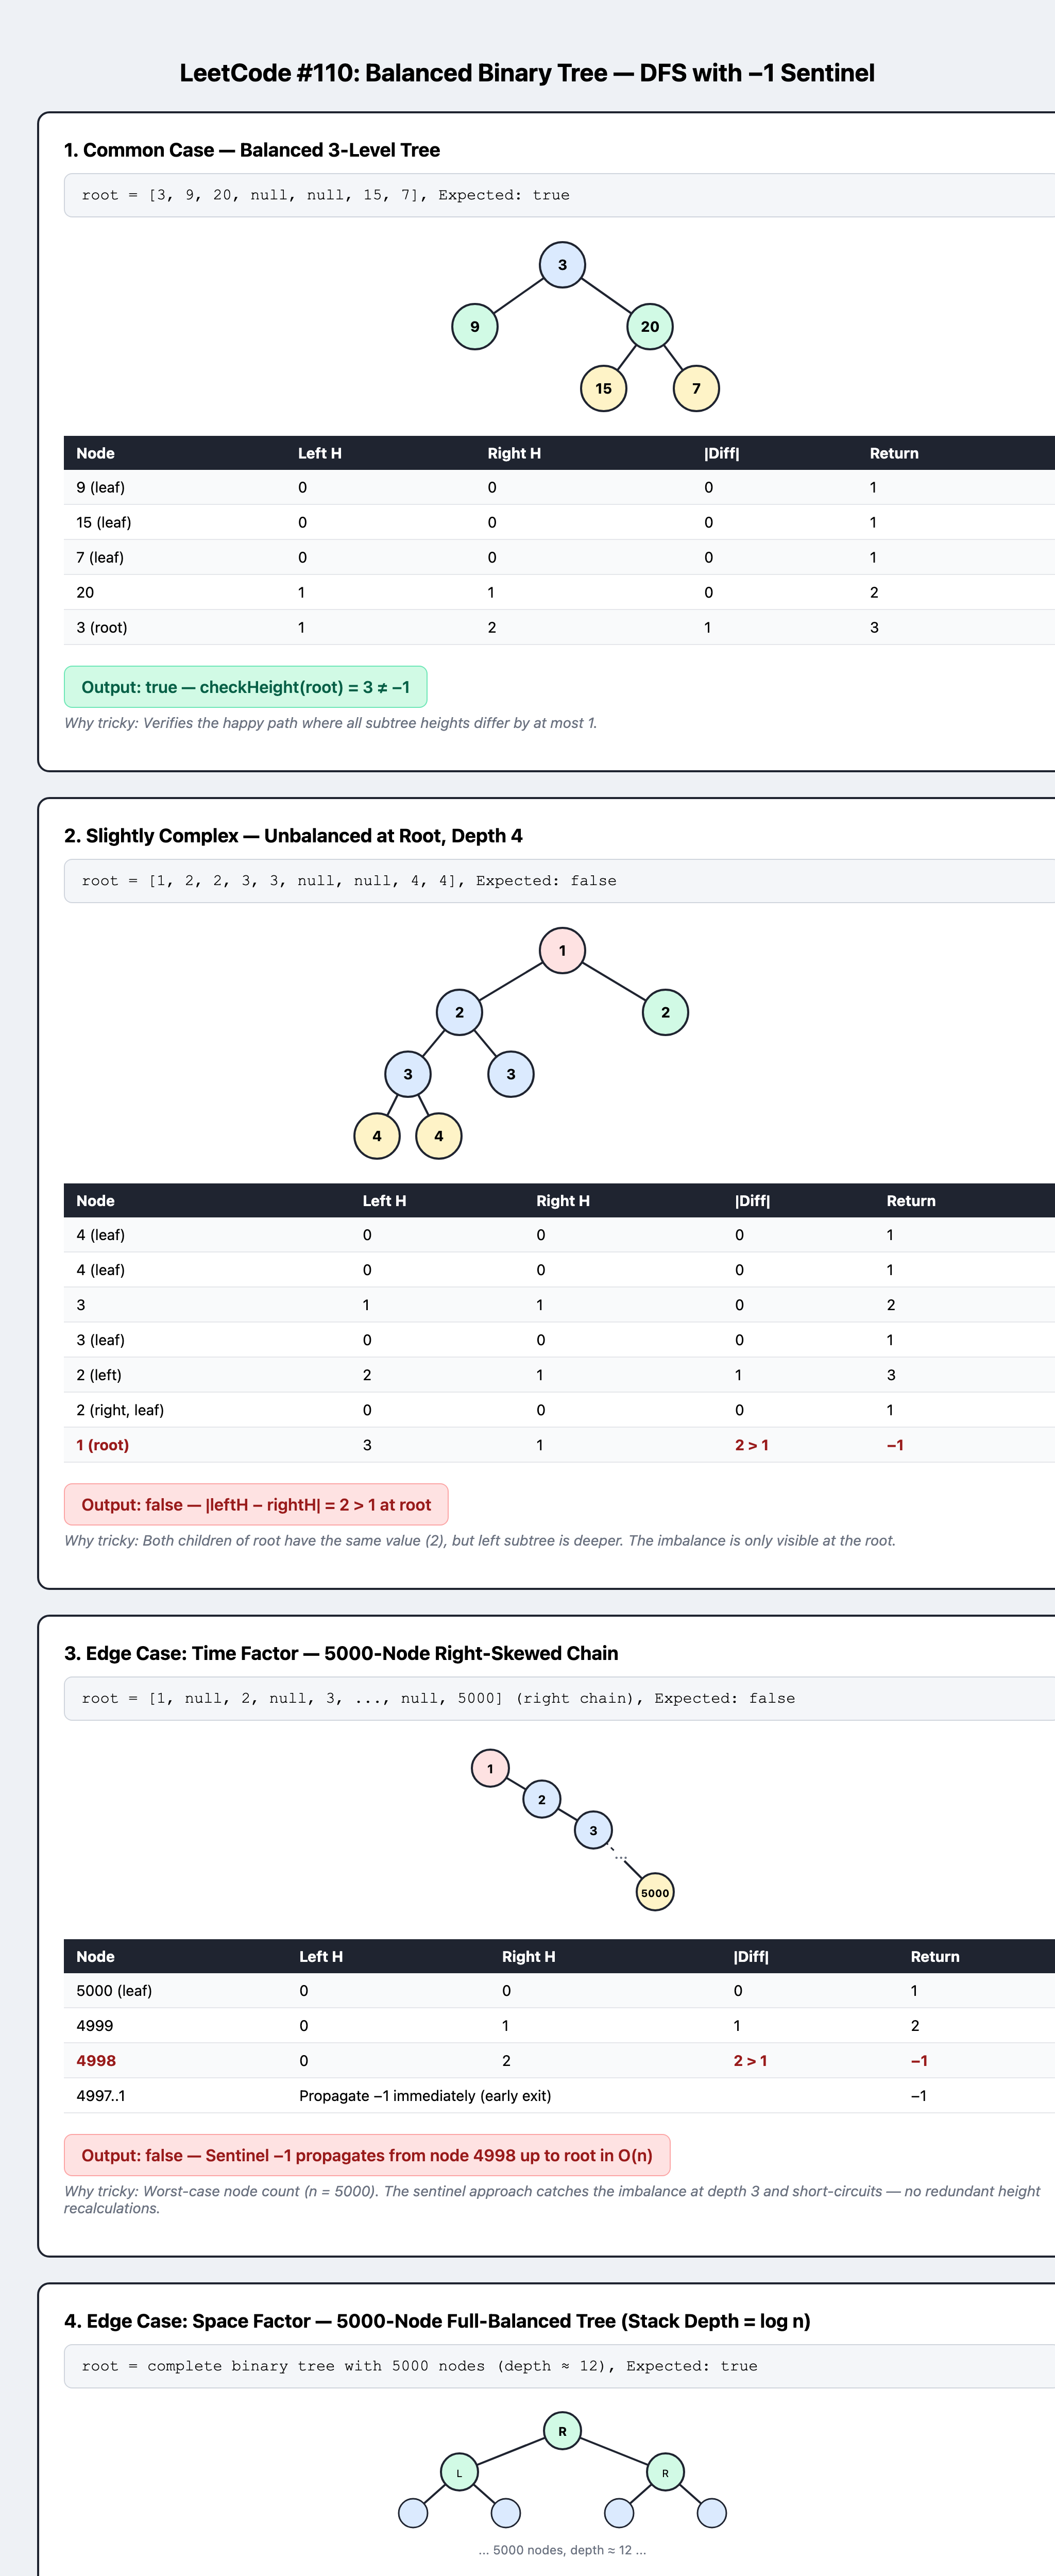